# 🏢 HR Employee Attrition Analysis & Prediction

In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install nltk
!pip install xgboost
!pip install lightgbm
!pip install vaderSentiment


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Data manipulation and numerical computing
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, 
                             roc_auc_score, confusion_matrix, 
                             classification_report)
import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to C:\Users\Rishika
[nltk_data]     Sinha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Rishika
[nltk_data]     Sinha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Rishika
[nltk_data]     Sinha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Rishika
[nltk_data]     Sinha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Module 1 — Data Loading & Cleaning

In [4]:
# Loading the dataset
df = pd.read_csv(r"C:\Users\Rishika Sinha\Desktop\IBM HR Analytics.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# Creating a working copy to preserve original data
df_copy = df.copy()
df_copy.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [6]:
df_copy.shape

(1470, 35)

In [7]:
df_copy.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [11]:
df_copy.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df_copy['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
# Checking for duplicate rows
print("Duplicate rows:", df_copy.shape[0] - df_copy.drop_duplicates().shape[0])

Duplicate rows: 0


In [10]:
print("\nUnique values in useless columns:")
print("EmployeeCount:", df_copy['EmployeeCount'].unique())
print("Over18:", df_copy['Over18'].unique())
print("StandardHours:", df_copy['StandardHours'].unique())


Unique values in useless columns:
EmployeeCount: [1]
Over18: <StringArray>
['Y']
Length: 1, dtype: str
StandardHours: [80]


In [11]:
# Dropping useless columns - single unique value adds no information
df_copy.drop(columns = ['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)
print("\nShape after dropping useless columns:", df_copy.shape)


Shape after dropping useless columns: (1470, 32)


In [12]:
print("Before encoding:", df_copy['Attrition'].unique())

Before encoding: <StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [13]:
# Encoding target variable - Yes=1 (Left), No=0 (Stayed)
df_copy['Attrition'] = df_copy['Attrition'].map({'Yes': 1, 'No': 0})
print("After encoding:", df_copy['Attrition'].unique())
print(df_copy['Attrition'].value_counts())

After encoding: [1 0]
Attrition
0    1233
1     237
Name: count, dtype: int64


## Module 2 — SQL Analysis

In [15]:
#Load into SQLite
conn = sqlite3.connect(':memory:')
df_copy.to_sql('employees', conn, index=False, if_exists='replace')

1470

In [16]:
# Married vs Unmarried Count and Attrition Rate
query1 = """
Select MaritalStatus, Count(*) as TotalCount, Sum(Attrition) as AtrCount, Round(Sum(Attrition)*100.0 / Count(*),2) as AttritionRate
From employees Group By MaritalStatus Order By AttritionRate DESC;
"""

print("--- Marital Status vs Attrition ---")
print(pd.read_sql_query(query1, conn))



--- Marital Status vs Attrition ---
  MaritalStatus  TotalCount  AtrCount  AttritionRate
0        Single         470       120          25.53
1       Married         673        84          12.48
2      Divorced         327        33          10.09


In [35]:
# Salary Range VS Attrition
query2 = """
Select Case When MonthlyIncome < 3000 Then 'Low (<3000)'
            WHEN MonthlyIncome Between 3000 and 7000 Then 'Medium (3000-7000)'
            WHEN MonthlyIncome Between 7001 and 15000 Then 'High (7001-15000)'
            Else 'Very High (> 15000)'
End as SalaryRange,
Count(*) as TotalCount, Sum(Attrition) as AtrCount, Round(Sum(Attrition)*100.0 / Count(*),2) as AttritionRate
From Employees Group By SalaryRange Order By AttritionRate DESC;

"""

print("--- Salary Range vs Attrition ---")
print(pd.read_sql_query(query2, conn))

--- Salary Range vs Attrition ---
           SalaryRange  TotalCount  AtrCount  AttritionRate
0          Low (<3000)         395       113          28.61
1    High (7001-15000)         302        42          13.91
2   Medium (3000-7000)         640        77          12.03
3  Very High (> 15000)         133         5           3.76


In [18]:
# Salary Hike VS Attrition
query3 = """
Select Case When PercentSalaryHike Between 11 and 14 Then 'Low Hike (11-14%)'
            When PercentSalaryHike Between 15 and 19 Then 'Medium Hike (15-19%)'
            Else 'High Hike (> 20%)'
End as HikeRange,
Count(*) as TotalCount, Sum(Attrition) as AtrCount, Round(Sum(Attrition)*100.0 / Count(*),2) as AttritionRate
From Employees Group By HikeRange Order By AttritionRate DESC;

"""

print("--- Salary Hike vs Attrition ---")
print(pd.read_sql_query(query3, conn))


--- Salary Hike vs Attrition ---
              HikeRange  TotalCount  AtrCount  AttritionRate
0     High Hike (> 20%)         226        37          16.37
1     Low Hike (11-14%)         818       132          16.14
2  Medium Hike (15-19%)         426        68          15.96


In [19]:
# Overtime Vs Attrition
query4 = """
Select Overtime, Count(*) as TotalCount, Sum(Attrition) as AtrCount, Round(Sum(Attrition)*100.0 / Count(*),2) as AttritionRate
From Employees Group By Overtime Order By AttritionRate DESC;

"""
print("--- Salary Overtime vs Attrition ---")
print(pd.read_sql_query(query4, conn))

--- Salary Overtime vs Attrition ---
  OverTime  TotalCount  AtrCount  AttritionRate
0      Yes         416       127          30.53
1       No        1054       110          10.44


In [34]:
# Promotion Status Vs Attrition
query5 = """
Select Case When YearsSinceLastPromotion = 0 Then 'Just Promoted'
            When YearsSinceLastPromotion Between 1 and 3 Then 'Promoted 1-3 Years Ago'
            When YearsSinceLastPromotion Between 4 and 7 Then 'Overdue 4 -7 Years'
            Else 'Long Overdue(> 7 Years)'
End as PromotionStatus,
Count(*) as TotalCount, Sum(Attrition) as AtrCount, Round(Sum(Attrition)*100.0 / Count(*),2) as AttritionRate
From Employees Group By PromotionStatus Order By AttritionRate DESC; 
"""
print("--- PromotionStatus vs Attrition ---")
print(pd.read_sql_query(query5, conn))

--- PromotionStatus vs Attrition ---
           PromotionStatus  TotalCount  AtrCount  AttritionRate
0            Just Promoted         581       110          18.93
1   Promoted 1-3 Years Ago         568        85          14.96
2       Overdue 4 -7 Years         214        29          13.55
3  Long Overdue(> 7 Years)         107        13          12.15


In [20]:
# Job Satisfaction VS Attrition
query6 = """
Select Case When JobSatisfaction =1 Then 'Very Dissatisfied'
            When JobSatisfaction =2 Then 'Dissatisfied'
            When JobSatisfaction =3 Then 'Satisfied'
            Else 'Very Satisfied'
END as SatisfactionLevel,
Count(*) as TotalCount, Sum(Attrition) as AtrCount, Round(Sum(Attrition)*100.0 / Count(*),2) as AttritionRate
From Employees Group By JobSatisfaction Order By AttritionRate DESC;  

"""

print("--- JobSatisfaction vs Attrition ---")
print(pd.read_sql_query(query6, conn))

--- JobSatisfaction vs Attrition ---
   SatisfactionLevel  TotalCount  AtrCount  AttritionRate
0  Very Dissatisfied         289        66          22.84
1          Satisfied         442        73          16.52
2       Dissatisfied         280        46          16.43
3     Very Satisfied         459        52          11.33


In [21]:
# Department VS Attrition
dept_attrition = df_copy.groupby("Department")['Attrition'].agg(TotalCount = 'count', AtrCount = 'sum')
dept_attrition['AttritionRate'] = round(dept_attrition['AtrCount'] * 100.0 / dept_attrition['TotalCount'], 2)
print("--- Department vs Attrition ---")
print(dept_attrition.sort_values('AttritionRate', ascending=False))

--- Department vs Attrition ---
                        TotalCount  AtrCount  AttritionRate
Department                                                 
Sales                          446        92          20.63
Human Resources                 63        12          19.05
Research & Development         961       133          13.84


In [22]:
# Age Group VS Attrition
print("\n--- Age Group vs Attrition ---")
df_copy['AgeGroup'] = pd.cut(df_copy['Age'], bins = [18, 25, 35, 45, 60], labels= ['18-25', '26-35', '36-45', '46-60'])
age_attrition = df_copy.groupby("AgeGroup")['Attrition'].agg(TotalCount = 'count', AtrCount = 'sum')
age_attrition['AttritionRate'] = round(age_attrition['AtrCount'] * 100.0 / age_attrition['TotalCount'],2)
print(age_attrition.sort_values('AttritionRate', ascending=False))


--- Age Group vs Attrition ---
          TotalCount  AtrCount  AttritionRate
AgeGroup                                     
18-25            115        40          34.78
26-35            606       116          19.14
46-60            273        34          12.45
36-45            468        43           9.19


In [23]:
# Education VS Attrition
edu_map = {1:'Below College', 2:'College', 3:'Bachelor', 4:'Masters', 5:'Doctorate'}
df_copy['EducationLevel'] = df_copy['Education'].map(edu_map)
edu_attrition = df_copy.groupby("Education")['Attrition'].agg(TotalCount= 'count', AtrCount = 'sum')
edu_attrition['AttritionRate'] = round(edu_attrition['AtrCount'] * 100.0 / edu_attrition['TotalCount'], 2)

print("\n--- Education Level vs Attrition ---")
print(edu_attrition.sort_values('AttritionRate', ascending=False))


--- Education Level vs Attrition ---
           TotalCount  AtrCount  AttritionRate
Education                                     
1                 170        31          18.24
3                 572        99          17.31
2                 282        44          15.60
4                 398        58          14.57
5                  48         5          10.42


## Module 3 — EDA & Visualizations

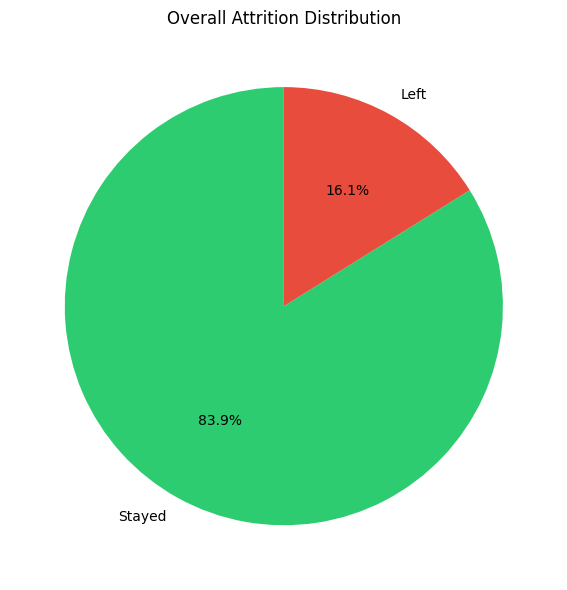

In [24]:
# Pie-Chart showing Overall Attrition
labels = ['Stayed', 'Left']
sizes = df_copy['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Overall Attrition Distribution')
plt.tight_layout()
plt.show()


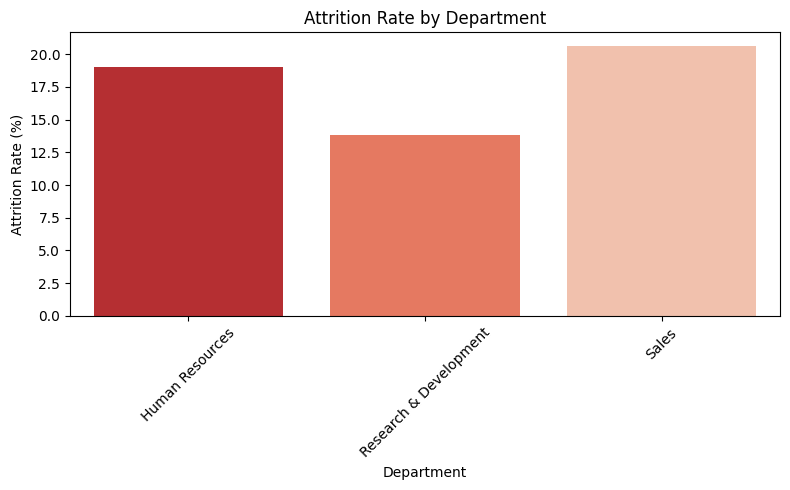

In [26]:
# Bar Chart Showing Departmemnt VS Attrition Rate
dept_plot = dept_attrition.reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=dept_plot, x='Department', y='AttritionRate', palette='Reds_r')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

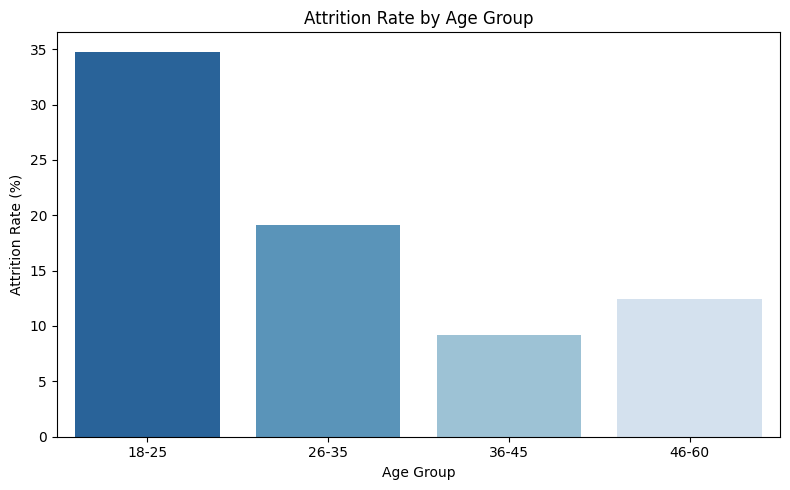

In [27]:
# Bar Chart showing Age Group vs Attrition Rate
age_plot = age_attrition.reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=age_plot, x='AgeGroup', y='AttritionRate', palette='Blues_r')
plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

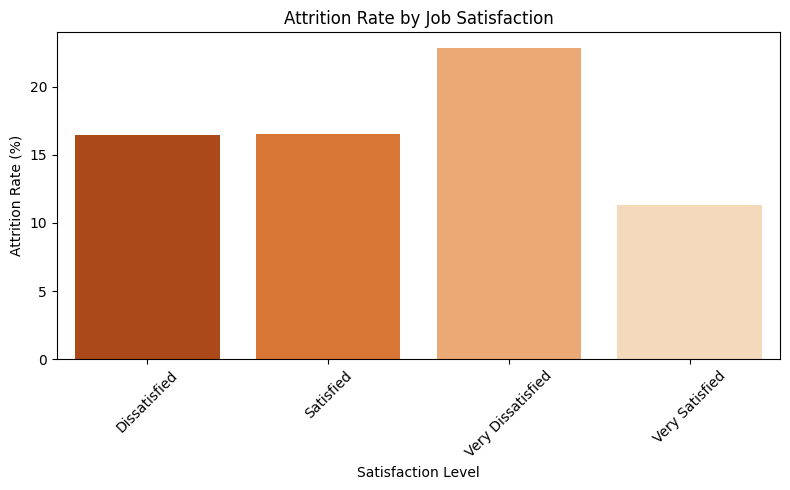

In [28]:
# Bar Chart showing Job Satisfaction vs Attrition Rate

satisfaction_map = {1:'Very Dissatisfied', 2:'Dissatisfied', 3:'Satisfied', 4:'Very Satisfied'}
df_copy['SatisfactionLevel'] = df_copy['JobSatisfaction'].map(satisfaction_map)

sat_plot = df_copy.groupby('SatisfactionLevel')['Attrition'].mean().reset_index()
sat_plot.columns = ['SatisfactionLevel', 'AttritionRate']
sat_plot['AttritionRate'] = sat_plot['AttritionRate'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=sat_plot, x='SatisfactionLevel', y='AttritionRate', palette='Oranges_r')
plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Satisfaction Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

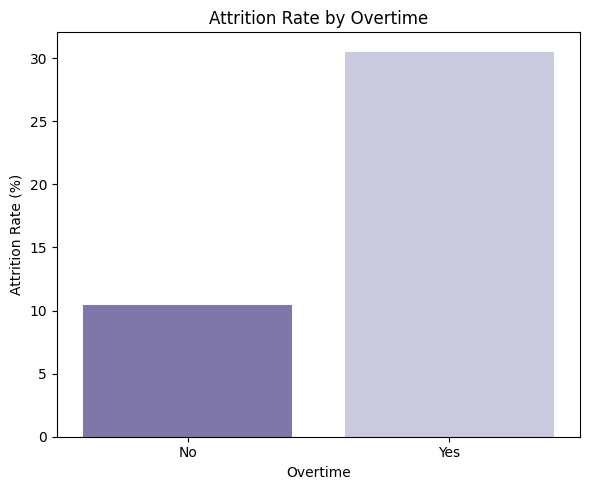

In [29]:
# Bar Chart showing Overtime vs Attrition Rate

overtime_plot = df_copy.groupby('OverTime')['Attrition'].mean().reset_index()
overtime_plot.columns = ['OverTime', 'AttritionRate']
overtime_plot['AttritionRate'] = overtime_plot['AttritionRate'] * 100

plt.figure(figsize=(6, 5))
sns.barplot(data=overtime_plot, x='OverTime', y='AttritionRate', palette='Purples_r')
plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

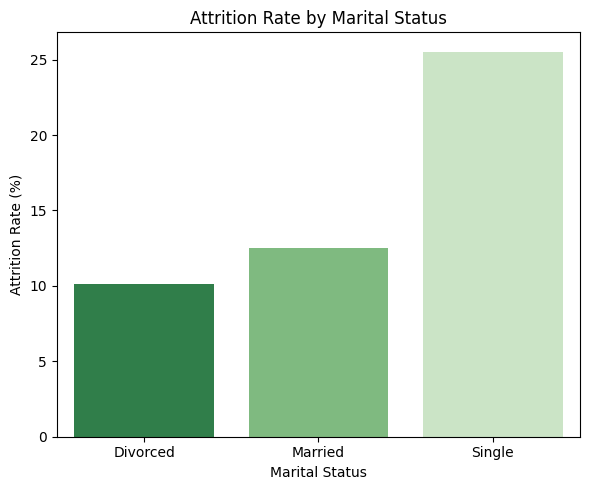

In [30]:
# Bar Chart showing Marital Status vs Attrition Rate
marital_plot = df_copy.groupby('MaritalStatus')['Attrition'].mean().reset_index()
marital_plot.columns = ['MaritalStatus', 'AttritionRate']
marital_plot['AttritionRate'] = marital_plot['AttritionRate'] * 100

plt.figure(figsize=(6, 5))
sns.barplot(data=marital_plot, x='MaritalStatus', y='AttritionRate', palette='Greens_r')
plt.title('Attrition Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

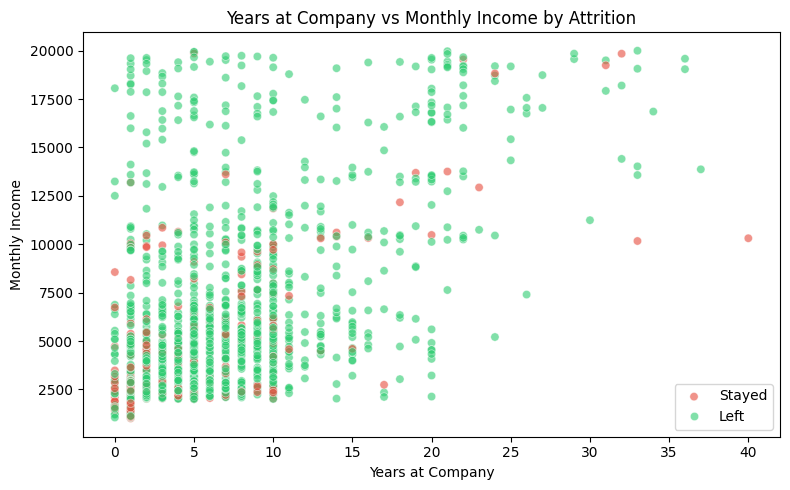

In [31]:
# Scatter Plot showing Years at Company vs Monthly Income
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_copy, x='YearsAtCompany', y='MonthlyIncome',hue='Attrition', palette={0:'#2ecc71', 1:'#e74c3c'}, alpha=0.6)
plt.title('Years at Company vs Monthly Income by Attrition')
plt.xlabel('Years at Company')
plt.ylabel('Monthly Income')
plt.legend(labels=['Stayed', 'Left'])
plt.tight_layout()
plt.show()

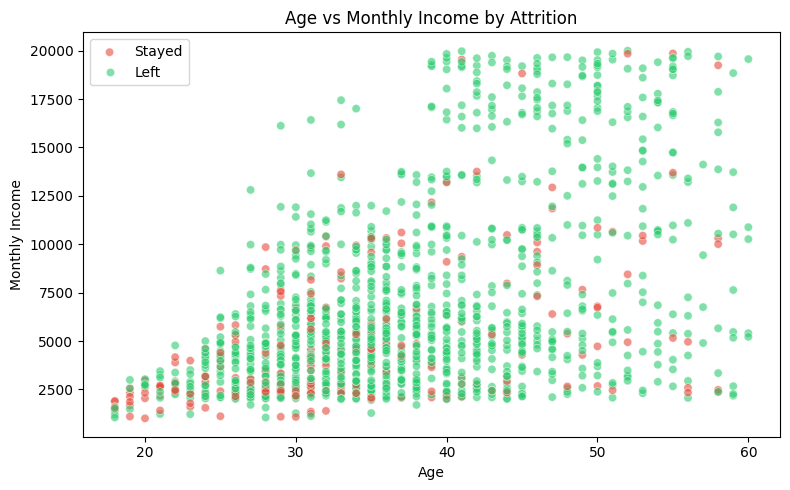

In [33]:
# Scatter showing Age vs Monthly Income
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_copy, x='Age', y='MonthlyIncome', hue='Attrition', palette={0:'#2ecc71', 1:'#e74c3c'},alpha=0.6)
plt.title('Age vs Monthly Income by Attrition')
plt.xlabel('Age')
plt.ylabel('Monthly Income')
plt.legend(labels=['Stayed', 'Left'])
plt.tight_layout()
plt.show()

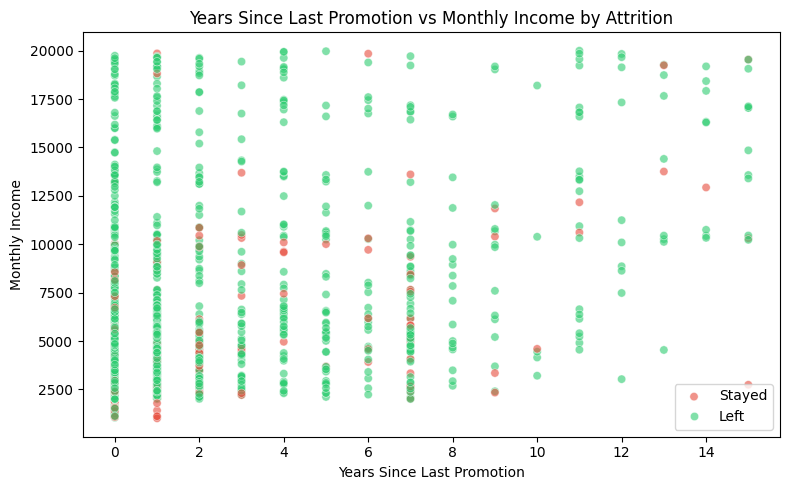

In [34]:
# Scatter showing Years Since Last Promotion vs Monthly Income
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_copy, x='YearsSinceLastPromotion', y='MonthlyIncome',  hue='Attrition', palette={0:'#2ecc71', 1:'#e74c3c'},alpha=0.6)
plt.title('Years Since Last Promotion vs Monthly Income by Attrition')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Monthly Income')
plt.legend(labels=['Stayed', 'Left'])
plt.tight_layout()
plt.show()

## Module 4 — NLP & TF-IDF

In [35]:
# Creating text column combining JobRole, Department, EducationField
df_copy['TextFeature'] = df_copy['JobRole'] + ' ' + df_copy['Department'] + ' ' + df_copy['EducationField']
left_text = ' '. join(df_copy[df_copy['Attrition'] == 1]['TextFeature'].values)
stayed_text = ' '.join(df_copy[df_copy['Attrition'] == 0]['TextFeature'].values)

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=10)
tfidf_matrix = tfidf.fit_transform([left_text, stayed_text])

features = tfidf.get_feature_names_out()
left_scores = tfidf_matrix[0].toarray()[0]
stayed_scores = tfidf_matrix[1].toarray()[0]

tfidf_df = pd.DataFrame({'Feature': features, 'Left_Score': left_scores, 'Stayed_Score': stayed_scores}).sort_values('Left_Score', ascending=False)
print("--- TF-IDF: Top Keywords for Employees Who Left ---")
print(tfidf_df)

--- TF-IDF: Top Keywords for Employees Who Left ---
       Feature  Left_Score  Stayed_Score
6        sales    0.532323      0.366677
5     research    0.532323      0.627111
0  development    0.389005      0.451128
7     sciences    0.260312      0.281682
3         life    0.260312      0.281682
4      medical    0.184266      0.218481
9   technician    0.181341      0.107333
2   laboratory    0.181341      0.107333
1    executive    0.166717      0.146562
8    scientist    0.137468      0.133486


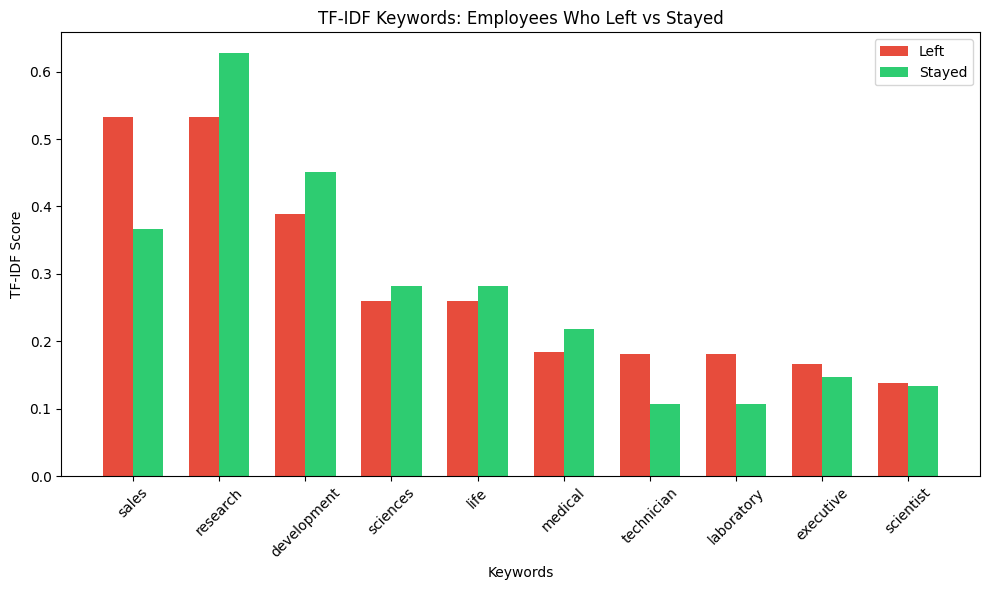

In [36]:
# Visualization
plt.figure(figsize=(10, 6))
x = range(len(tfidf_df))
width = 0.35

plt.bar([i -width/2 for i in x], tfidf_df['Left_Score'], width=width, color='#e74c3c', label='Left')
plt.bar([i + width/2 for i in x], tfidf_df['Stayed_Score'], width=width, color='#2ecc71', label='Stayed')

plt.xticks(x, tfidf_df['Feature'], rotation=45)
plt.title('TF-IDF Keywords: Employees Who Left vs Stayed')
plt.xlabel('Keywords')
plt.ylabel('TF-IDF Score')
plt.legend()
plt.tight_layout()
plt.show()

## Module 5 — Feature Engineering & SMOTE

In [37]:
# Feature Engineering
df_copy['PromotionRisk'] = (df_copy['YearsSinceLastPromotion'] >=3).astype(int)
df_copy['HikeRisk'] = (df_copy['PercentSalaryHike'] <= 14).astype(int)
df_copy['OvertimeRisk'] = ((df_copy['OverTime'] == 'Yes') & (df_copy['MonthlyIncome'] < 5000)).astype(int)
print("New columns created:")
print("PromotionRisk:", df_copy['PromotionRisk'].value_counts().to_dict())
print("HikeRisk:", df_copy['HikeRisk'].value_counts().to_dict())
print("OvertimeRisk:", df_copy['OvertimeRisk'].value_counts().to_dict())

New columns created:
PromotionRisk: {0: 1097, 1: 373}
HikeRisk: {1: 818, 0: 652}
OvertimeRisk: {0: 1265, 1: 205}


## Module 6 — Machine Learning Prediction

In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

binary_cols = ['OverTime', 'Gender', 'BusinessTravel']
for col in binary_cols:
    df_copy[col] = le.fit_transform(df_copy[col])

df_copy = pd.get_dummies(df_copy, columns=['Department', 'JobRole','MaritalStatus','EducationField'], drop_first=True)

df_copy.drop(columns=['TextFeature', 'AgeGroup', 'EducationLevel', 'SatisfactionLevel'], inplace=True)

print("Shape after encoding:", df_copy.shape)


Shape after encoding: (1470, 48)


In [41]:
# Defining features and target
X = df_copy.drop(columns=['Attrition'])
y = df_copy['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:", y_train.value_counts().to_dict())
print("y_test distribution:", y_test.value_counts().to_dict())

X_train shape: (1176, 47)
X_test shape: (294, 47)
y_train distribution: {0: 986, 1: 190}
y_test distribution: {0: 247, 1: 47}


Logistic Regression
  Accuracy : 0.8673
  F1 Score : 0.3390
  ROC-AUC  : 0.6023


<Figure size 500x400 with 0 Axes>

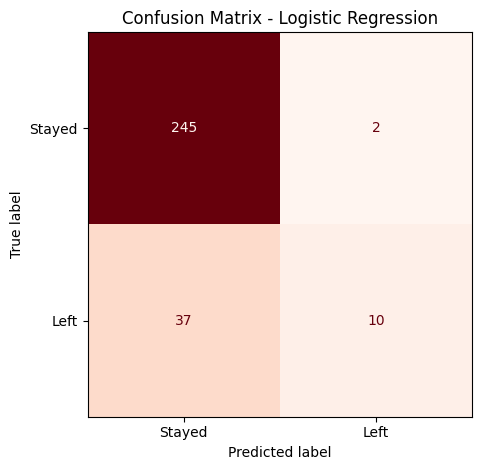

In [45]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_pred_lr):.4f}")


plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['Stayed','Left'],colorbar=False, cmap='Reds')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

Random Forest
Accuracy : 0.8401
F1 Score : 0.2034
ROC-AUC  : 0.5517


<Figure size 500x400 with 0 Axes>

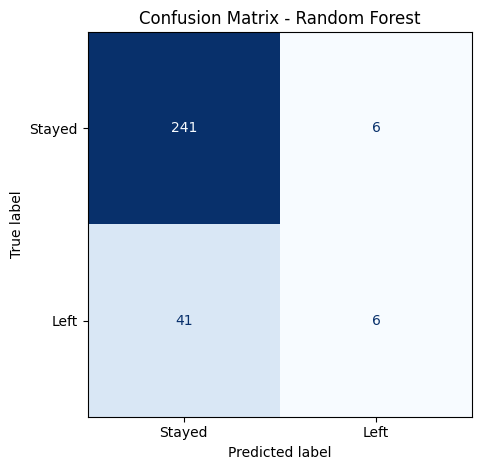

In [48]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_rf):.4f}")

plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Stayed','Left'], colorbar=False, cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

XGBoost
Accuracy : 0.8673
F1 Score : 0.4000
ROC-AUC  : 0.6282


<Figure size 500x400 with 0 Axes>

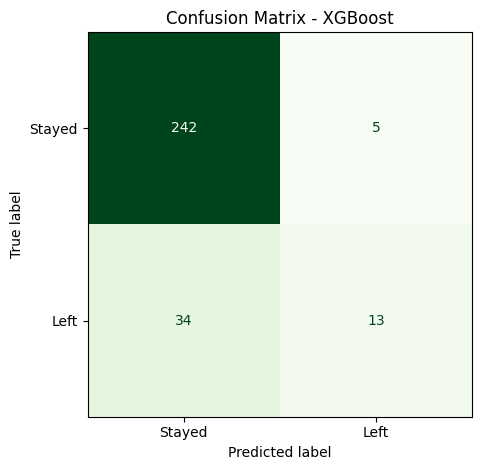

In [46]:
# XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_xgb):.4f}")

plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=['Stayed','Left'],colorbar=False, cmap='Greens')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.show()


In [49]:
# Comparing accuracy score of all the 3 models
results = {
        'Logistic Regression': [accuracy_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr),  roc_auc_score(y_test, y_pred_lr)],
        'Random Forest':       [accuracy_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_pred_rf)],
        'XGBoost':             [accuracy_score(y_test, y_pred_xgb),f1_score(y_test, y_pred_xgb), roc_auc_score(y_test, y_pred_xgb)]
}

results_df = pd.DataFrame(results, index=['Accuracy', 'F1 Score', 'ROC-AUC']).T
print(results_df.sort_values('ROC-AUC', ascending=False))

                     Accuracy  F1 Score   ROC-AUC
XGBoost              0.867347  0.400000  0.628176
Logistic Regression  0.867347  0.338983  0.602334
Random Forest        0.840136  0.203390  0.551684


In [50]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Stayed: {sum(y_train == 0)}  Left: {sum(y_train == 1)}")
print("\nAfter SMOTE:")
print(f"  Stayed: {sum(y_train_sm == 0)}  Left: {sum(y_train_sm == 1)}")


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Before SMOTE:
  Stayed: 986  Left: 190

After SMOTE:
  Stayed: 986  Left: 986


In [51]:
# Defining confusion matrix function
def plot_confusion_matrix(y_test, y_pred, model_name, color):
    print(f"\n--- {model_name} ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred):.4f}")
    
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Stayed', 'Left'], colorbar=False, cmap=color)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()


--- Logistic Regression + SMOTE ---
Accuracy : 0.7619
F1 Score : 0.3750
ROC-AUC  : 0.6343


<Figure size 500x400 with 0 Axes>

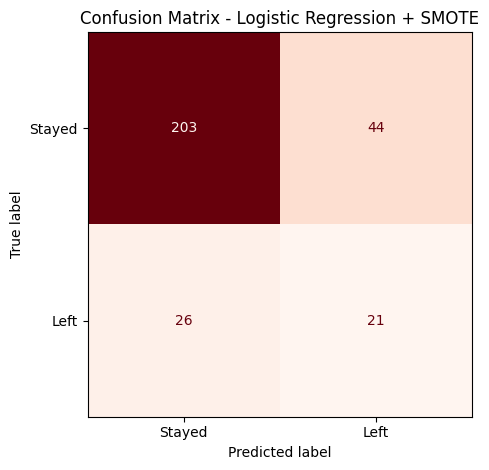


--- Random Forest + SMOTE ---
Accuracy : 0.8367
F1 Score : 0.3333
ROC-AUC  : 0.6013


<Figure size 500x400 with 0 Axes>

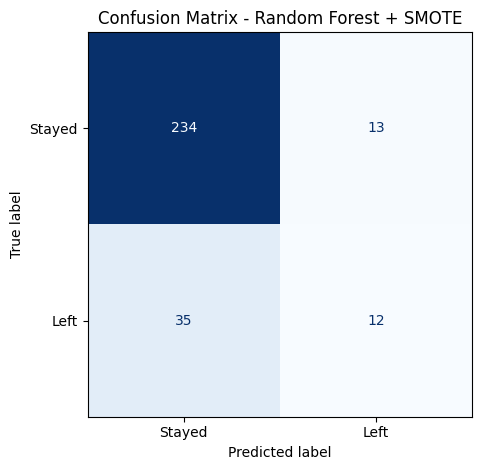


--- XGBoost + SMOTE ---
Accuracy : 0.8571
F1 Score : 0.4167
ROC-AUC  : 0.6393


<Figure size 500x400 with 0 Axes>

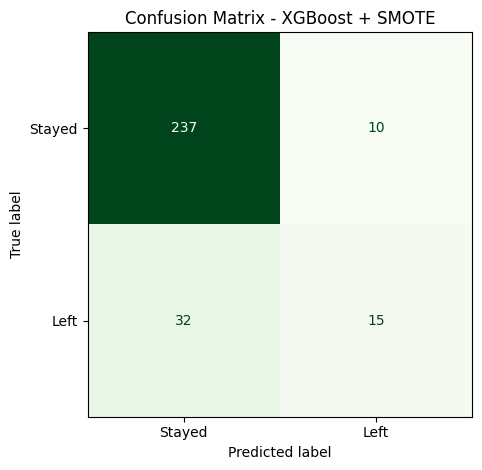

In [52]:
# Retraining with SMOTE data
lr_sm = LogisticRegression(max_iter=1000, random_state=42)
lr_sm.fit(X_train_sm, y_train_sm)
y_pred_lr_sm = lr_sm.predict(X_test)
plot_confusion_matrix(y_test, y_pred_lr_sm, 'Logistic Regression + SMOTE', 'Reds')

rf_sm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)
y_pred_rf_sm = rf_sm.predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf_sm, 'Random Forest + SMOTE', 'Blues')

xgb_sm = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_sm.fit(X_train_sm, y_train_sm)
y_pred_xgb_sm = xgb_sm.predict(X_test)
plot_confusion_matrix(y_test, y_pred_xgb_sm, 'XGBoost + SMOTE', 'Greens')

In [91]:
# Comparing results after SMOTE
results_sm = {
    'LR + SMOTE':  [accuracy_score(y_test, y_pred_lr_sm), f1_score(y_test, y_pred_lr_sm),roc_auc_score(y_test, y_pred_lr_sm)],
    'RF + SMOTE':  [accuracy_score(y_test, y_pred_rf_sm),   f1_score(y_test, y_pred_rf_sm), roc_auc_score(y_test, y_pred_rf_sm)],
    'XGB + SMOTE': [accuracy_score(y_test, y_pred_xgb_sm),f1_score(y_test, y_pred_xgb_sm), roc_auc_score(y_test, y_pred_xgb_sm)]
}

results_sm_df = pd.DataFrame(results_sm, index=['Accuracy', 'F1 Score', 'ROC-AUC']).T
print("\n--- Results After SMOTE ---")
print(results_sm_df.sort_values('ROC-AUC', ascending=False))


--- Results After SMOTE ---
             Accuracy  F1 Score   ROC-AUC
XGB + SMOTE  0.857143  0.416667  0.639332
LR + SMOTE   0.761905  0.375000  0.634335
RF + SMOTE   0.836735  0.333333  0.601344


In [55]:
from sklearn.metrics import classification_report, precision_score, recall_score

print("XGBoost + SMOTE — Full Classification Report")
print(classification_report(y_test, y_pred_xgb_sm, target_names=['Stayed', 'Left']))

print(f"Precision (Left) : {precision_score(y_test, y_pred_xgb_sm):.4f}")
print(f"Recall    (Left) : {recall_score(y_test, y_pred_xgb_sm):.4f}")
print(f"F1 Score  (Left) : {f1_score(y_test, y_pred_xgb_sm):.4f}")

XGBoost + SMOTE — Full Classification Report
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.60      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294

Precision (Left) : 0.6000
Recall    (Left) : 0.3191
F1 Score  (Left) : 0.4167


In [56]:
# Threshold Tuning
from sklearn.metrics import classification_report

proba = xgb_sm.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.4, 0.5]:
    preds = (proba >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, preds, target_names=['Stayed', 'Left']))


Threshold: 0.3
              precision    recall  f1-score   support

      Stayed       0.89      0.92      0.91       247
        Left       0.50      0.43      0.46        47

    accuracy                           0.84       294
   macro avg       0.70      0.67      0.68       294
weighted avg       0.83      0.84      0.83       294


Threshold: 0.4
              precision    recall  f1-score   support

      Stayed       0.88      0.95      0.92       247
        Left       0.57      0.34      0.43        47

    accuracy                           0.85       294
   macro avg       0.73      0.65      0.67       294
weighted avg       0.83      0.85      0.84       294


Threshold: 0.5
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.60      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.84   

Top 15 Features Driving Attrition
                              Feature  Importance
31                   Department_Sales    0.109490
19                   StockOptionLevel    0.096108
32            JobRole_Human Resources    0.091094
41               MaritalStatus_Single    0.073354
10                           JobLevel    0.071987
40              MaritalStatus_Married    0.064616
30  Department_Research & Development    0.032466
11                    JobSatisfaction    0.030660
43           EducationField_Marketing    0.029473
46    EducationField_Technical Degree    0.021640
45               EducationField_Other    0.021523
44             EducationField_Medical    0.020812
37         JobRole_Research Scientist    0.020099
6             EnvironmentSatisfaction    0.020027
33      JobRole_Laboratory Technician    0.018370


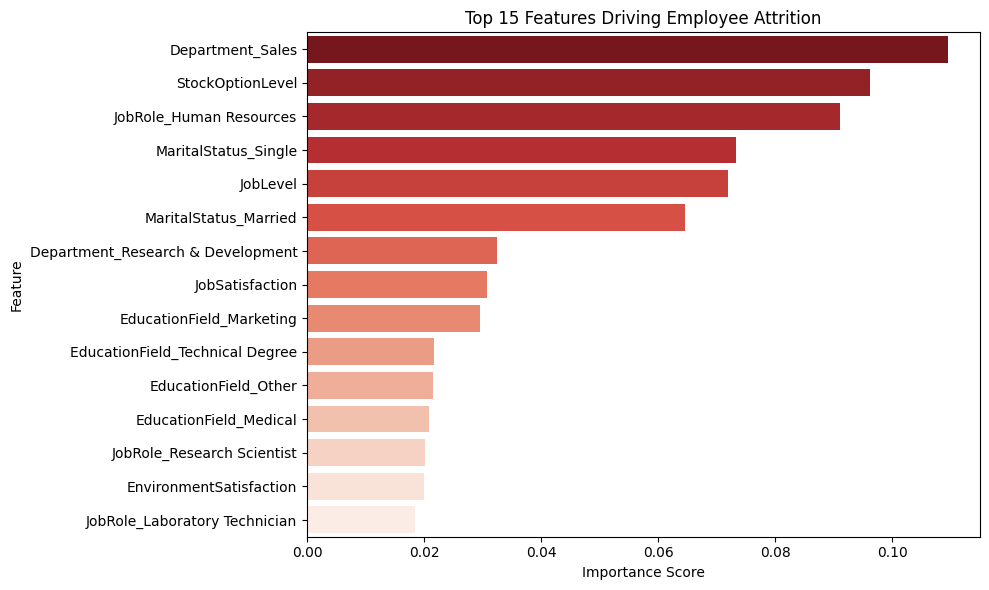

In [57]:
# Feature Importance - XGBoost
feature_importance = pd.DataFrame({'Feature': X_train.columns,'Importance': xgb_sm.feature_importances_}).sort_values('Importance', ascending=False).head(15)
print("Top 15 Features Driving Attrition")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='Reds_r')
plt.title('Top 15 Features Driving Employee Attrition')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [58]:
# Generating risk score using XGBoost+SMOTE
risk_scores = xgb_sm.predict_proba(X_test)[:,1]

df_risk = X_test.copy()
df_risk['AttritionRisk'] = (risk_scores * 100).round(2)
df_risk['ActualAttrition'] = y_test.values
df_risk['RiskLevel'] = pd.cut(df_risk['AttritionRisk'],bins=[0, 30, 60, 100],labels=['Low', 'Medium', 'High'])

print("Top 10 High Risk Employees")
print(df_risk[['AttritionRisk', 'RiskLevel', 'ActualAttrition']] .sort_values('AttritionRisk', ascending=False).head(10))

print("\n--- Risk Level Distribution ---")
print(df_risk['RiskLevel'].value_counts())

print("\n Business Problem Risk Counts")
print(f"High Risk Employees: {(df_risk['RiskLevel'] == 'High').sum()}")
print(f"Medium Risk Employees: {(df_risk['RiskLevel'] == 'Medium').sum()}")
print(f"Low Risk Employees: {(df_risk['RiskLevel'] == 'Low').sum()}")

Top 10 High Risk Employees
      AttritionRisk RiskLevel  ActualAttrition
744       99.860001      High                1
911       99.790001      High                1
688       99.650002      High                1
357       99.139999      High                1
711       98.980003      High                1
301       98.860001      High                0
1391      97.559998      High                0
684       96.910004      High                0
1061      92.919998      High                0
182       92.430000      High                1

--- Risk Level Distribution ---
RiskLevel
Low       251
High       22
Medium     18
Name: count, dtype: int64

 Business Problem Risk Counts
High Risk Employees: 22
Medium Risk Employees: 18
Low Risk Employees: 251


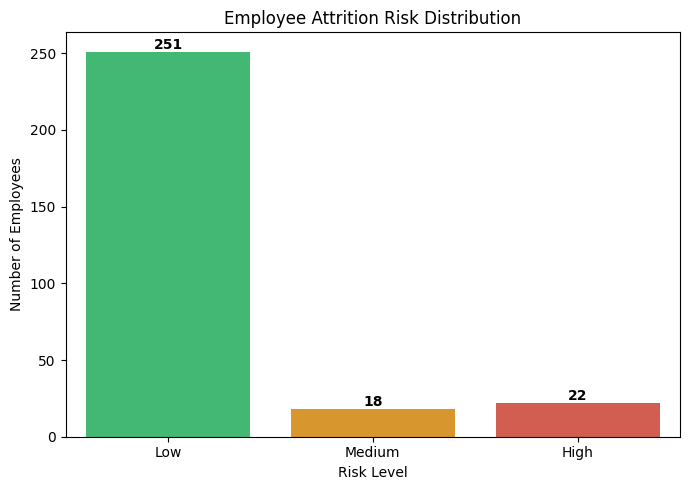

In [59]:
# Risk Level Distribution Chart
risk_order = ['Low', 'Medium', 'High']
risk_counts = df_risk['RiskLevel'].value_counts().reindex(risk_order).reset_index()
risk_counts.columns = ['RiskLevel', 'Count']

plt.figure(figsize=(7, 5))
sns.barplot(data=risk_counts, x='RiskLevel', y='Count',palette={'High':'#e74c3c', 'Medium':'#f39c12', 'Low':'#2ecc71'})
plt.title('Employee Attrition Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Employees')
for i, row in risk_counts.iterrows():
    plt.text(i, row['Count'] + 2, str(row['Count']),
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

This project analyzed IBM HR data to predict employee attrition.
- XGBoost + SMOTE achieved best performance — Accuracy 85.7%, ROC-AUC 0.6393
- Key drivers — Sales department, overtime, low salary and single marital status
- 22 high risk employees identified for immediate HR intervention